# 🎓 Espacios de Color y Segmentación

En esta sesión aprenderemos a manipular los colores de una imagen para aislar objetos de interés. 

### 🎯 Objetivos de Aprendizaje
1.  Entender la diferencia entre **BGR**, **RGB**, **Grayscale** y **HSV**.
2.  Convertir imágenes entre diferentes espacios de color.
3.  Realizar **segmentación por color** para detectar objetos.
4.  Crear máscaras binarias.

---

## 1. Teoría de Espacios de Color

### 1.1 RGB vs BGR
* **RGB (Red, Green, Blue):** Es el estándar en pantallas y la mayoría de librerías.
* **BGR (Blue, Green, Red):** Es el estándar histórico de **OpenCV**. 

### 1.2 HSV (Hue, Saturation, Value)
Detectar un color en RGB es difícil porque la información de "color" y "brillo" está mezclada en los tres canales. 

* **H (Hue/Matiz):** El color puro (0-179 en OpenCV). Por ejemplo, el rojo está cerca del 0 y del 180.
* **S (Saturation):** Qué tan intenso es el color (0-255).
* **V (Value):** Qué tan brillante es (0-255).

**¿Por qué usamos HSV?** Porque nos permite separar la información cromática (H) de la iluminación (V), haciendo la detección mucho más robusta a sombras o cambios de luz.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Función auxiliar para mostrar imágenes con Matplotlib
def mostrar_imagen(titulo, imagen, cmap=None):
    plt.figure(figsize=(6,6))
    if cmap:
        plt.imshow(imagen, cmap=cmap)
    else:
        # Convertir BGR a RGB para mostrar correctamente
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

## 2. Conversión de Espacios de Color

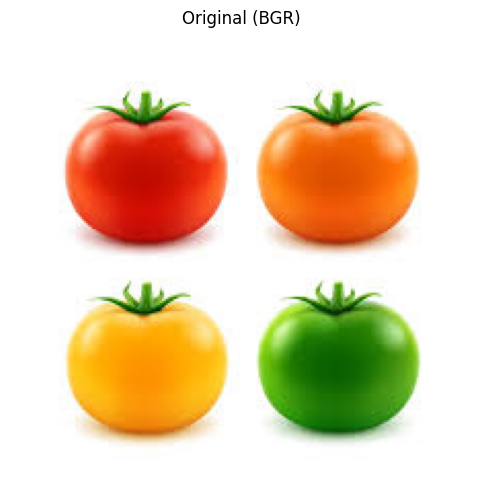

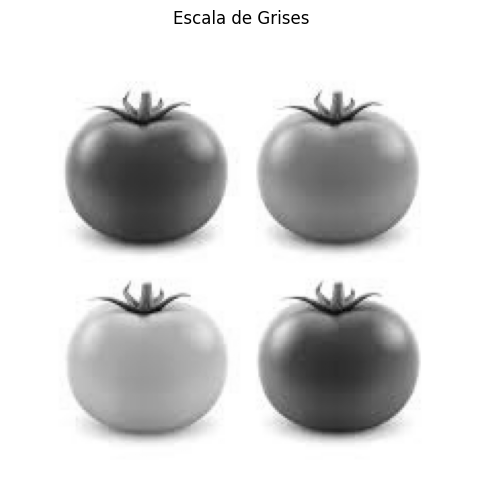

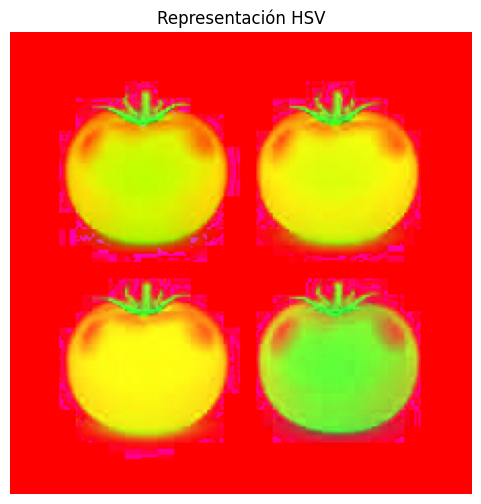

In [2]:
# Cargar una imagen de prueba (asegúrate de tener 'frutas.jpg' o similar)
imagen = cv2.imread('frutas.jpg')

if imagen is None:
    # Crear imagen sintética si no existe archivo
    imagen = np.zeros((300, 300, 3), dtype=np.uint8)
    cv2.circle(imagen, (150, 150), 100, (0, 0, 255), -1) # Círculo rojo (en BGR)
    cv2.rectangle(imagen, (50, 50), (100, 100), (0, 255, 0), -1) # Cuadro verde

# 1. Convertir a Escala de Grises
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

# 2. Convertir a HSV
hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

# Mostrar resultados
mostrar_imagen("Original (BGR)", imagen)
mostrar_imagen("Escala de Grises", gris, cmap='gray')
# Nota: Visualizar HSV directamente como RGB se ve extraño, 
# pero es útil ver que los datos han cambiado.
mostrar_imagen("Representación HSV", hsv) 

### 2.1 Desglosando los Canales
Podemos separar una imagen en sus componentes individuales usando `cv2.split`.

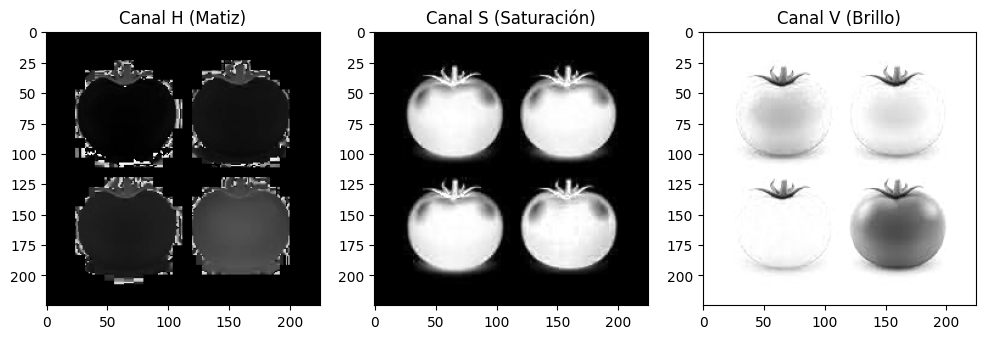

In [3]:
# Separar canales HSV
h, s, v = cv2.split(hsv)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(h, cmap='gray')
plt.title('Canal H (Matiz)')

plt.subplot(1, 3, 2)
plt.imshow(s, cmap='gray')
plt.title('Canal S (Saturación)')

plt.subplot(1, 3, 3)
plt.imshow(v, cmap='gray')
plt.title('Canal V (Brillo)')

plt.show()

## 3. Segmentación por Color (Máscaras)

La función clave aquí es `cv2.inRange`. Esta función crea una máscara binaria (blanco/negro) donde los píxeles blancos son aquellos que caen dentro del rango de color que definimos.

**Ejemplo:** Vamos a detectar el color **ROJO**.

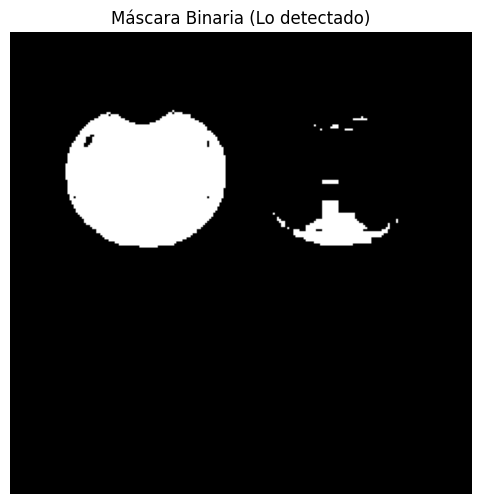

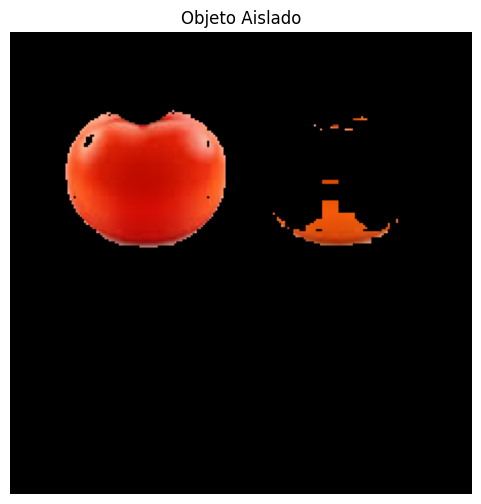

In [4]:
# Definir rangos para el color ROJO en HSV
# El rojo en HSV está al principio (0-10) y al final (170-180) del espectro.

# Rango rojo 1
rojo_bajo1 = np.array([0, 100, 100])
rojo_alto1 = np.array([10, 255, 255])

# Rango rojo 2
rojo_bajo2 = np.array([170, 100, 100])
rojo_alto2 = np.array([180, 255, 255])

# Crear máscaras
mascara1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
mascara2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)

# Combinar máscaras (Operación OR)
mascara_final = cv2.bitwise_or(mascara1, mascara2)

# Aplicar la máscara a la imagen original (Operación AND)
resultado = cv2.bitwise_and(imagen, imagen, mask=mascara_final)

mostrar_imagen("Máscara Binaria (Lo detectado)", mascara_final, cmap='gray')
mostrar_imagen("Objeto Aislado", resultado)

## 4. Práctica Interactiva (Webcam)

Vamos a implementar un **Detector de Color en Tiempo Real**. 

> **Nota:** Si ejecutas esto localmente, se abrirá una ventana. Usa los trackbars (barras deslizantes) si sabes implementarlos, o ajusta los valores `azul_bajo` y `azul_alto` manualmente en el código.

In [5]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

# Definir rango inicial para color AZUL
azul_bajo = np.array([100, 50, 50])
azul_alto = np.array([130, 255, 255])

print("🟦 Iniciando detector de AZUL. Presiona 'q' para salir.")

while True:
    ret, frame = cap.read()
    if not ret: break

    # 1. Convertir a HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2. Crear Máscara
    mask = cv2.inRange(hsv, azul_bajo, azul_alto)

    # 3. Filtrar el frame original usando la máscara
    res = cv2.bitwise_and(frame, frame, mask=mask)

    # Mostrar ventanas
    cv2.imshow('Original', frame)
    cv2.imshow('Mascara', mask)
    cv2.imshow('Resultado', res)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🟦 Iniciando detector de AZUL. Presiona 'q' para salir.


## 5. 🚀 Mini-Proyecto: Clasificador de Frutas por Color

**Descripción:**
Crea un script que cargue una imagen con varias frutas (ej. plátano, manzana, naranja) y:
1. Genere una máscara para el amarillo (plátanos).
2. Genere una máscara para el rojo (manzanas).
3. Cuente cuántos píxeles hay de cada color (`cv2.countNonZero`) para determinar qué fruta predomina en la imagen.

In [1]:
# TODO: Implementa el mini-proyecto aquí

import cv2
import numpy as np

# --- 1. Generación de Imagen de Prueba (Para no necesitar archivos externos) ---
# Creamos una imagen sintética con un círculo rojo (Manzana) y una elipse amarilla (Plátano)
imagen = np.zeros((400, 400, 3), dtype=np.uint8)
imagen[:] = 255 # Fondo blanco

# Dibujar "Manzana" (Círculo Rojo)
# Nota: En OpenCV el rojo es (0, 0, 255) -> BGR
cv2.circle(imagen, (100, 200), 60, (0, 0, 255), -1) 

# Dibujar "Plátano" (Elipse Amarilla)
# Nota: Amarillo es Rojo + Verde -> (0, 255, 255) en BGR
cv2.ellipse(imagen, (300, 200), (80, 30), 45, 0, 360, (0, 255, 255), -1)

# --- 2. Lógica del Clasificador ---

# Convertir a espacio de color HSV (Matiz, Saturación, Valor)
hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

# Definir rangos de color en HSV
# El ROJO es especial en HSV: está al principio (0-10) y al final (170-180) del espectro
rojo_bajo1 = np.array([0, 100, 100])
rojo_alto1 = np.array([10, 255, 255])
rojo_bajo2 = np.array([170, 100, 100])
rojo_alto2 = np.array([180, 255, 255])

# El AMARILLO suele estar entre 20 y 30
amarillo_bajo = np.array([20, 100, 100])
amarillo_alto = np.array([30, 255, 255])

# Crear Máscaras
# Para el rojo unimos los dos rangos
mask_rojo1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
mask_rojo2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)
mask_rojo = cv2.bitwise_or(mask_rojo1, mask_rojo2)

mask_amarillo = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)

# Contar píxeles detectados (Área del color)
pixels_rojo = cv2.countNonZero(mask_rojo)
pixels_amarillo = cv2.countNonZero(mask_amarillo)

print(f"📊 Análisis de Frutas:")
print(f"   - Píxeles Rojos detectados: {pixels_rojo}")
print(f"   - Píxeles Amarillos detectados: {pixels_amarillo}")

# --- 3. Resultados y Visualización ---

print("\n🍎 RESULTADO FINAL:")
if pixels_rojo > pixels_amarillo:
    print(">> Predomina la MANZANA (Rojo)")
elif pixels_amarillo > pixels_rojo:
    print(">> Predomina el PLÁTANO (Amarillo)")
else:
    print(">> No se identifica una fruta predominante")

# Mostrar imágenes
cv2.imshow("Original", imagen)
cv2.imshow("Mascara Rojo (Manzana)", mask_rojo)
cv2.imshow("Mascara Amarillo (Platano)", mask_amarillo)

print("\nPresiona cualquier tecla en las ventanas para cerrar...")
cv2.waitKey(0)
cv2.destroyAllWindows()

📊 Análisis de Frutas:
   - Píxeles Rojos detectados: 11289
   - Píxeles Amarillos detectados: 7688

🍎 RESULTADO FINAL:
>> Predomina la MANZANA (Rojo)

Presiona cualquier tecla en las ventanas para cerrar...
